# Prefect + Dask

This is a tutorial to use the Prefect and Dask clusters together from Jupyter.

NOTE: we can use the EOPF Dask cluster from Prefect, but not the staging cluster because of dependency conflicts.

See the associated Python module: [my_prefect_and_dask.py](./my_prefect_and_dask.py)

In [1]:
import os
print(f"Prefect server URL used internally: {os.environ['PREFECT_API_URL']}")
dashboard = f"{os.environ['PREFECT_PUBLIC']}/dashboard"
print(f"Prefect dashboard public URL: {dashboard}")

Prefect server URL used internally: http://prefect-server:4200/api
Prefect dashboard public URL: http://localhost:4200/dashboard


In [2]:
# Init environment before running a demo notebook.
from resources.utils import *  
from resources.dask_utils import *
from resources.prefect_utils import *

init_demo()
init_dask_cluster_eopf(scale=2)

# Reload the global vars again
from resources.utils import *  
from resources.dask_utils import *  
from resources.prefect_utils import *

Auxip service: http://rs-server-adgs:8000
CADIP service: http://rs-server-cadip:8000
Catalog service: http://rs-server-catalog:8000
Connecting to dask gateway for 'dask-eopf': http://dask-eopf:8000 ...
Dask dashboard for 'dask-eopf': http://localhost:8702/clusters/9c2a38c32b364aa4ba7f204544eafd30/status


/opt/conda/lib/python3.11/site-packages/distributed/client.py:1394: VersionMismatchWarning: Mismatched versions found

+---------+--------+-----------+---------+
| Package | Client | Scheduler | Workers |
+---------+--------+-----------+---------+
| tornado | 6.3.3  | 6.4.2     | None    |
+---------+--------+-----------+---------+
  warnings.warn(version_module.VersionMismatchWarning(msg[0]["warning"]))


In [3]:
%%bash
prefect block ls
echo -e "\nNOTE: you can see the block details and credentials by running e.g.: prefect block inspect s3-bucket/s3"

                                  Blocks                                  
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━━━┓
┃ ID                                   ┃ Type      ┃ Name ┃ Slug         ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━━━━┩
│ c0104524-36d8-4896-af91-fa9feed6c8e6 │ S3 Bucket │ s3   │ s3-bucket/s3 │
│ 7994ace5-c161-44f1-841a-acf75d2cb554 │ Secret    │ auth │ secret/auth  │
└──────────────────────────────────────┴───────────┴──────┴──────────────┘
              List Block Types using `prefect block type ls`              

NOTE: you can see the block details and credentials by running e.g.: prefect block inspect s3-bucket/s3


In [4]:
# Other imports
import getpass
import os
import time
from importlib import reload
from resources import prefect_utils

# Data to test the example flow
my_data = {"start": "2000", "end": "2001", "freq": "2w"}

# Data as a command-line string in the json format
my_data_str = json.dumps(my_data)
my_data_str = my_data_str.replace('"', r'\"')

In [5]:
# We use only the EOPF dask cluster in this tutorial
dask_gateway = dask_gateway_eopf
dask_client = dask_client_eopf
dask_cluster = dask_cluster_eopf

# Save cluster info to be read by our flow
os.environ["DASK_CLUSTER_NAME"] = dask_cluster.name

# Set environment variables for the client and dask workers
def set_dask_env():
    os.environ["HELLO_FROM"] = "dask"
dask_client.run(set_dask_env)
time.sleep(1)
os.environ["HELLO_FROM"] = "client"

# 1. Call Prefect flow from Python code

In [6]:
# Import the module, or reload it if you changed its source code
import my_prefect_and_dask
reload(my_prefect_and_dask)

# Call flow and print results
result = my_prefect_and_dask.my_flow(**my_data)
#display(result.head()) # we have strange errors with this line, I don't know why, maybe a dependency version problem

/opt/conda/lib/python3.11/site-packages/distributed/client.py:1394: VersionMismatchWarning: Mismatched versions found

+---------+--------+-----------+---------+
| Package | Client | Scheduler | Workers |
+---------+--------+-----------+---------+
| tornado | 6.3.3  | 6.4.2     | 6.4.2   |
+---------+--------+-----------+---------+
  warnings.warn(version_module.VersionMismatchWarning(msg[0]["warning"]))


13:00:40.774 | WARNING | root - Hello from 'client' '172.18.0.21' (main code)

/opt/conda/lib/python3.11/site-packages/distributed/client.py:1394: VersionMismatchWarning: Mismatched versions found

+---------+--------+-----------+---------+
| Package | Client | Scheduler | Workers |
+---------+--------+-----------+---------+
| tornado | 6.3.3  | 6.4.2     | 6.4.2   |
+---------+--------+-----------+---------+
  warnings.warn(version_module.VersionMismatchWarning(msg[0]["warning"]))


13:00:40.878 | WARNING | root - Hello from 'client' '172.18.0.21' (main code)

13:00:40.955 | INFO    | prefect.engine - Created flow run 'valiant-lori' for flow 'my-flow'

...

13:00:40.985 | INFO    | prefect.task_runner.dask - Connecting to existing Dask cluster GatewayCluster<9c2a38c32b364aa4ba7f204544eafd30, status=running>

/opt/conda/lib/python3.11/site-packages/distributed/client.py:1394: VersionMismatchWarning: Mismatched versions found

+---------+--------+-----------+---------+
| Package | Client | Scheduler | Workers |
+---------+--------+-----------+---------+
| tornado | 6.3.3  | 6.4.2     | 6.4.2   |
+---------+--------+-----------+---------+
  warnings.warn(version_module.VersionMismatchWarning(msg[0]["warning"]))


13:00:41.007 | WARNING | Flow run 'valiant-lori' - Hello from 'client' '172.18.0.21' (flow)

13:00:54.293 | WARNING | Flow run 'valiant-lori' - 
Results:
Dask DataFrame Structure:
                    id        x        y
npartitions=1                           
               float64  float64  float64
                   ...      ...      ...
Dask Name: concat, 9 expressions
Expr=Concat(frames=[ArrowStringConversion(frame=FromMap(4da9466))['id'].describenumeric(split_every=False, percentile_method='default'), ArrowStringConversion(frame=FromMap(4da9466))['x'].describenumeric(split_every=False, percentile_method='default'), ArrowStringConversion(frame=FromMap(4da9466))['y'].describenumeric(split_every=False, percentile_method='default')], axis=1)

13:00:54.314 | INFO    | Flow run 'valiant-lori' - Finished in state Completed()

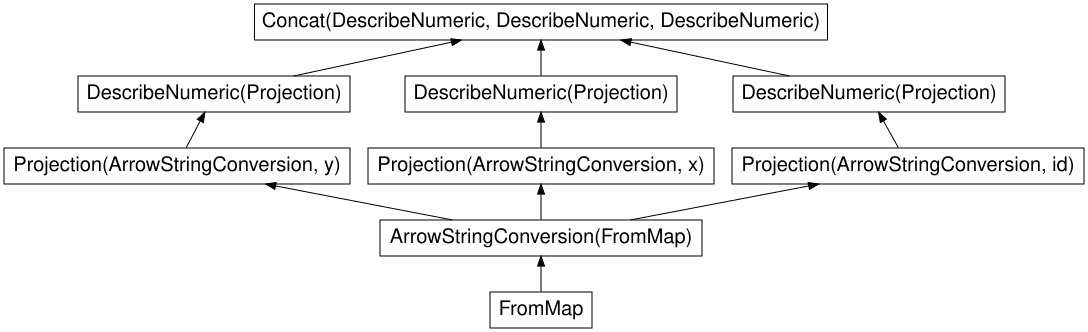

In [7]:
# Visualize the dask graph
result.visualize(filename=None, tasks=False)

<div class="alert alert-info" role="alert">
Notes:

  1. In the Prefect dashboard (see link above), find your run, check its graph and logs.
  1. Check in the dashboard and above logs that when we call the flow from Python code, no Prefect workers are involved:
      1. Your module main code (outside functions) and flow are run only by client.
      1. The tasks are run only by the Dask workers.
  1. If you want to check the IP adresses:
      1. On kubernetes, you can run the `kubectl describe` command to check a pod IP address.
      1. In local mode, use: `docker inspect <container_id> | grep IPAddress`

# 2. Deploy Prefect flow

See the full yaml file: [deploy-prefect-dask.yaml](./deploy-prefect-dask.yaml)

First we deploy our source code via the S3 bucket.

In [8]:
# Use a subfolder named after the current user
s3_code_folder = f"users/{os.environ.get('RSPY_HOST_USER', getpass.getuser())}/code" 

if local_mode:
    print (f"S3 MinIO dashboard: http://localhost:9101 with user=minio password=Strong#Pass#1234")
print(f"Upload local source code and wheel to: 's3://{PREFECT_BLOCK_S3.bucket_name}/{PREFECT_BLOCK_S3.bucket_folder}/{s3_code_folder}'")

# Upload local directory contents
await PREFECT_BLOCK_S3.put_directory(local_path = ".", to_path = s3_code_folder)

# It doesn't follow symlinks so upload them manually
await PREFECT_BLOCK_S3.put_directory(local_path = "./resources", to_path = f"{s3_code_folder}/resources")

# Pass the full S3 code folder
os.environ["S3_CODE_FOLDER"] = f"{PREFECT_BLOCK_S3.bucket_folder}/{s3_code_folder}"

S3 MinIO dashboard: http://localhost:9101 with user=minio password=Strong#Pass#1234
Upload local source code and wheel to: 's3://prefect-share/sub/dir/users/jgaucher/code'


In [9]:
%%bash
# Deploy the flow. We don't need to be in the git root folder.
prefect --no-prompt deploy --prefect-file "./deploy-prefect-dask.yaml"

/opt/conda/lib/python3.11/site-packages/distributed/client.py:1394: VersionMismatchWarning: Mismatched versions found

+---------+--------+-----------+---------+
| Package | Client | Scheduler | Workers |
+---------+--------+-----------+---------+
| tornado | 6.3.3  | 6.4.2     | 6.4.2   |
+---------+--------+-----------+---------+
  warnings.warn(version_module.VersionMismatchWarning(msg[0]["warning"]))
13:00:56.784 | WARNING | root - Hello from 'client' '172.18.0.21' (main code)


╭──────────────────────────────────────────────────────────────────────────────╮
│ Deployment 'my-flow/tuto-prefect-dask' successfully created with id          │
│ '303f3a00-e2ac-4b3d-b2b5-3a06bc573822'.                                      │
╰──────────────────────────────────────────────────────────────────────────────╯

View Deployment in UI: http://prefect-server:4200/deployments/deployment/303f3a00-e2ac-4b3d-b2b5-3a06bc573822


To schedule a run for this deployment, use the following command:

        $ prefect deployment run 'my-flow/tuto-prefect-dask'



In [10]:
deploy_name = "my-flow/tuto-prefect-dask"
await prefect_utils.wait_for_deployment(deploy_name)

Finished deploying prefect flow: 'my-flow/tuto-prefect-dask'


In [11]:
%%bash -s "$deploy_name" "$my_data_str"
# Trigger a run for this flow from the command line
prefect deployment run "$1" --params "$2" --watch

Creating flow run for deployment 'my-flow/tuto-prefect-dask'...
Created flow run 'divergent-urchin'.
└── UUID: d2634594-fbe6-49b6-8fc2-4e6163c3d109
└── Parameters: {'start': '2000', 'end': '2001', 'freq': '2w'}
└── Job Variables: {}
└── Scheduled start time: 2025-02-04 13:00:58 UTC (now)
└── URL: http://prefect-server:4200/runs/flow-run/d2634594-fbe6-49b6-8fc2-4e6163c3d109
Watching flow run 'divergent-urchin'...


13:00:58.465 | INFO    | prefect - Flow run is in state 'Scheduled'
13:01:03.482 | INFO    | prefect - Flow run is in state 'Pending'


13:01:03.987 | WARNING | Flow run 'divergent-urchin' - Hello from 'dask' '172.18.0.14' (task)

13:01:03.987 | WARNING | Flow run 'divergent-urchin' - Hello from 'dask' '172.18.0.14' (task)

13:01:03.987 | WARNING | Flow run 'divergent-urchin' - Hello from 'dask' '172.18.0.14' (task)

...

13:01:09.648 | INFO    | Task run 'calling_compute_in_a_task' - Finished in state Completed()

13:01:09.648 | INFO    | Task run 'calling_compute_in_a_task' - Finished in state Completed()

13:01:09.648 | INFO    | Task run 'calling_compute_in_a_task' - Finished in state Completed()

13:01:13.528 | INFO    | prefect - Flow run is in state 'Completed'


Flow run finished successfully in 'Completed'.


<div class="alert alert-info" role="alert">
Notes:

  1. In the Prefect dashboard (see link above), find your run, check its graph and logs.
  1. Check in the dashboard and above logs that:
      1. Your module main code (outside functions) is run by the client and Prefect workers, not Dask workers.
      2. The flow is run only by the Prefect workers.
      1. The tasks are run only by the Dask workers.

## 3. Shutdown the dask clusters

In [12]:
# You can scale the clusters to 0 workers
dask_gateway_eopf.scale_cluster(dask_cluster_eopf.name, 0)

# # Or shutdown the clusters
shutdown_dask_clusters(dask_gateway_eopf)

# NOTE: restart your python kernel or terminal after the shutdown
# to avoid strange behaviour.

Shutting down cluster '9c2a38c32b364aa4ba7f204544eafd30' ...
